In [62]:
from scipy.io import loadmat
file_path = 'OPTI536_Homework_5/dataset_part_2.mat'
mat_data = loadmat(file_path)

print(mat_data.keys())

bin_width = mat_data['bin_width'] 
light_speed = mat_data['c'] 
num_bins = mat_data['num_bins'] 
source_detector_pairs = mat_data['source_detector_pairs'] 
tpsf = mat_data['tpsf']

print(f"bin_width shape: {bin_width.shape}")
print(f"bin_width data: {bin_width}")
print(f"num_bins shape -> width of each time bin (in seconds): {num_bins.shape}")
print(num_bins)
print(f"light_speed{light_speed.shape}: {light_speed}")
print(f"source_detector_pairs shape -> [numSources × numDetectors × 4] : {source_detector_pairs.shape}")
print(f"source_detector_pairs min and max : {source_detector_pairs.min()} : {source_detector_pairs.max()}")
print(f"tpsf shape -> time-resolved histograms of photon arrivals (transients):  \n 512 is the 3D matrix of ToF measurement data {tpsf.shape}")

dict_keys(['__header__', '__version__', '__globals__', 'bin_width', 'c', 'num_bins', 'source_detector_pairs', 'tpsf'])
bin_width shape: (1, 1)
bin_width data: [[1.e-10]]
num_bins shape -> width of each time bin (in seconds): (1, 1)
[[512]]
light_speed(1, 1): [[300000000]]
source_detector_pairs shape -> [numSources × numDetectors × 4] : (32, 32, 4)
source_detector_pairs min and max : -1.0 : 0.8
tpsf shape -> time-resolved histograms of photon arrivals (transients):  
 512 is the 3D matrix of ToF measurement data (32, 32, 512)


#  Question 1 a, b, c, and d

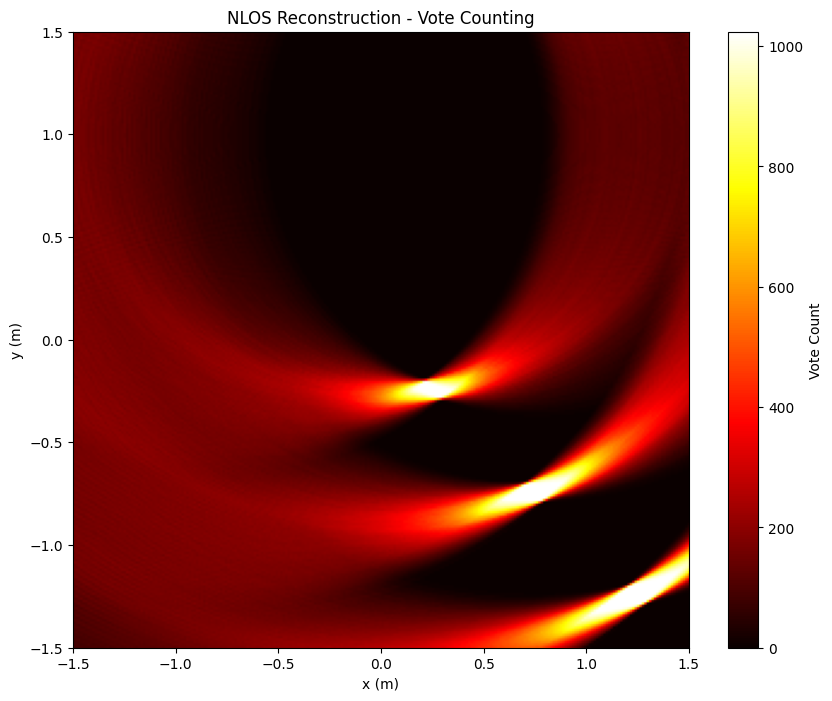

In [63]:
import numpy as np
import matplotlib.pyplot as plt

def reconstruct_nlos_image(source_detector_pairs, tpsf, light_speed, bin_width, grid_size=256, x_max=1.5):
    """
    Reconstruct NLOS image using elliptical backprojection
    
    Args:
        source_detector_pairs: Array of shape (num_sources, num_detectors, 4) containing [rs_x, rs_y, rd_x, rd_y]
        tpsf: Time-resolved measurements of shape (num_sources, num_detectors, num_time_bins)
        light_speed: Speed of light in m/s
        grid_size: Size of the reconstruction grid (grid_size × grid_size)
        x_max: Half-width of the reconstruction region in meters
        
    Returns:
        accumulator: The reconstructed image based on vote counting
    """
    # Set up the reconstruction grid
    x = np.linspace(-x_max, x_max, grid_size)
    y = np.linspace(-x_max, x_max, grid_size)
    X, Y = np.meshgrid(x, y)
    
    # Initialize accumulator for vote counting
    accumulator = np.zeros((grid_size, grid_size))
    
    # Define epsilon threshold (1-2 cm)
    epsilon = 0.015  # 1.5 cm threshold

    
    num_sources, num_detectors, num_time_bins = tpsf.shape
    
    # For each source-detector pair and time bin
    for s in range(num_sources):
        for d in range(num_detectors):
            # Get source and detector positions
            rs_x, rs_y, rd_x, rd_y = source_detector_pairs[s, d]
            
            # Calculate distances from each grid point to source and detector
            dist_to_source = np.sqrt((X - rs_x)**2 + (Y - rs_y)**2)
            dist_to_detector = np.sqrt((X - rd_x)**2 + (Y - rd_y)**2)
            
            # Total path lengths for all grid points
            total_path_lengths = dist_to_source + dist_to_detector
            
            # For each time bin
            for t in range(num_time_bins):
                # Skip if no photons detected
                if tpsf[s, d, t] <= 0:
                    continue
                
                t *= bin_width[0,0]
                # Calculate the expected path length for this time bin
                expected_path_length = light_speed[0, 0] * t 
                
                # Find grid points where the difference between total path length and expected path length is within epsilon
                # This exactly implements: if abs(dist(x, y) - c*t) < epsilon
                votes = np.abs(total_path_lengths - expected_path_length) < epsilon
                
                # Add votes to the accumulator (incrementing by 1 for each matching point)
                accumulator += votes
    
    return accumulator

# Main execution
if __name__ == "__main__":
    # Your data is already loaded
    # source_detector_pairs shape: (32, 32, 4)
    # tpsf shape: (32, 32, 512)
    # light_speed: [[300000000]]
    
    # Reconstruct the image
    accumulator = reconstruct_nlos_image(
        source_detector_pairs=source_detector_pairs,
        tpsf=tpsf,
        light_speed=light_speed,
        bin_width= bin_width,
        grid_size=256,
        x_max=1.5
    )
    
    # Visualize the result
    plt.figure(figsize=(10, 8))
    plt.imshow(accumulator, cmap='hot', extent=[-1.5, 1.5, -1.5, 1.5])
    plt.colorbar(label='Vote Count')
    plt.title('NLOS Reconstruction - Vote Counting')
    plt.xlabel('x (m)')
    plt.ylabel('y (m)')
    plt.show()

#  Question 1 e

/var/folders/6q/b1f95jp528qg7gf5zww7z9h80000gn/T/ipykernel_36664/1025919956.py:63: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(X, Y, inner_contour, levels=[0.5], colors=['blue'], linewidths=2,
/var/folders/6q/b1f95jp528qg7gf5zww7z9h80000gn/T/ipykernel_36664/1025919956.py:65: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(X, Y, outer_contour, levels=[0.5], colors=['red'], linewidths=2,
/var/folders/6q/b1f95jp528qg7gf5zww7z9h80000gn/T/ipykernel_36664/1025919956.py:74: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(X, Y, ideal_contour, levels=[0.5], colors=['black'],


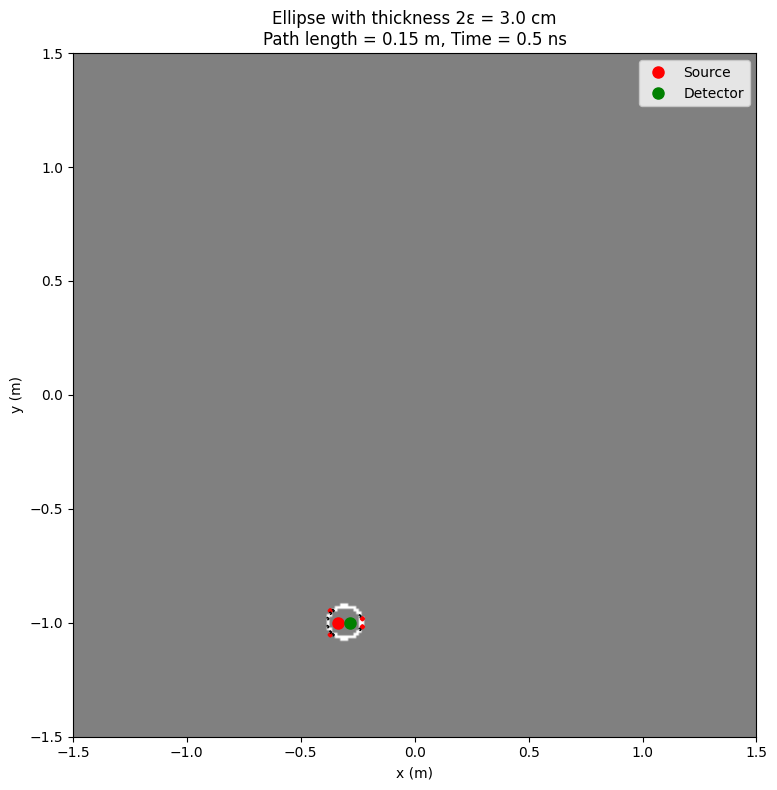

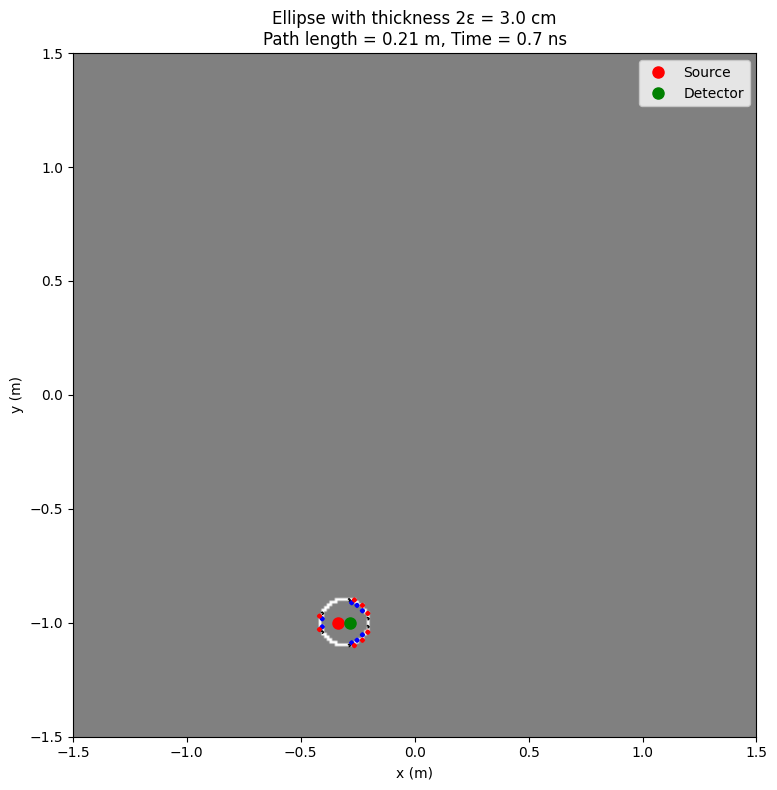

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_ellipse_thickness(source_detector_pairs, light_speed, s_idx=0, d_idx=0, t_idx=200, 
                              grid_size=256, x_max=1.5, time_resolution=1e-10):
    """
    Visualize the ellipse thickness based on the epsilon parameter
    
    Args:
        source_detector_pairs: Array with source-detector coordinates
        light_speed: Speed of light
        s_idx, d_idx: Source and detector indices
        t_idx: Time bin index
        grid_size: Grid resolution
        x_max: Half-width of reconstruction area
        time_resolution: Time bin width in seconds
    """
    c = light_speed[0, 0]
    
    # Set epsilon values for visualization
    epsilon_distance = 0.015  # 1.5 cm
    
    # Get source and detector positions
    rs_x, rs_y, rd_x, rd_y = source_detector_pairs[s_idx, d_idx]
    
    # Create the grid
    x = np.linspace(-x_max, x_max, grid_size)
    y = np.linspace(-x_max, x_max, grid_size)
    X, Y = np.meshgrid(x, y)
    
    # Calculate distances from each grid point to source and detector
    dist_to_source = np.sqrt((X - rs_x)**2 + (Y - rs_y)**2)
    dist_to_detector = np.sqrt((X - rd_x)**2 + (Y - rd_y)**2)
    
    # Total path lengths for all grid points
    total_path_lengths = dist_to_source + dist_to_detector
    
    # Expected path length for the given time bin
    expected_path_length = c * t_idx * time_resolution
    
    # Calculate difference from expected path length
    path_difference = np.abs(total_path_lengths - expected_path_length)
    
    # Plot
    plt.figure(figsize=(10, 8))
    
    # Create a mask for the elliptical shell (points within epsilon)
    ellipse_shell = path_difference < epsilon_distance
    
    # Plot the elliptical shell
    plt.imshow(ellipse_shell, extent=[-x_max, x_max, -x_max, x_max], 
               origin='lower', cmap='gray', alpha=0.5)
    
    # Plot contours for inner and outer boundaries
    inner_boundary = expected_path_length - epsilon_distance
    outer_boundary = expected_path_length + epsilon_distance

    # Full thickness = 2 × epsilon_distance = 2 × 0.015 m = 0.03 meters (3 centimeters)
    
    # Calculate contours
    inner_contour = np.abs(total_path_lengths - inner_boundary) < 0.001
    outer_contour = np.abs(total_path_lengths - outer_boundary) < 0.001
    
    # Plot contours
    plt.contour(X, Y, inner_contour, levels=[0.5], colors=['blue'], linewidths=2, 
               linestyles='solid', label='Inner boundary')
    plt.contour(X, Y, outer_contour, levels=[0.5], colors=['red'], linewidths=2, 
               linestyles='solid', label='Outer boundary')
    
    # Add source and detector points
    plt.plot(rs_x, rs_y, 'ro', markersize=8, label='Source')
    plt.plot(rd_x, rd_y, 'go', markersize=8, label='Detector')
    
    # Show the exact ellipse (ideal case with no thickness)
    ideal_contour = np.abs(total_path_lengths - expected_path_length) < 0.001
    plt.contour(X, Y, ideal_contour, levels=[0.5], colors=['black'], 
               linewidths=1, linestyles='dashed', label='Exact ellipse')
    
    plt.title(f'Ellipse with thickness 2ε = {2*epsilon_distance*100:.1f} cm\n'
              f'Path length = {expected_path_length:.2f} m, Time = {t_idx*time_resolution*1e9:.1f} ns')
    plt.xlabel('x (m)')
    plt.ylabel('y (m)')
    # plt.grid(True)
    # plt.colorbar(label='Within ε threshold')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Usage:
visualize_ellipse_thickness(
    source_detector_pairs=source_detector_pairs,
    light_speed=light_speed,
    s_idx=9,  # Source index
    d_idx=10, # Detector index
    t_idx=5 # Time bin
)

visualize_ellipse_thickness(
    source_detector_pairs=source_detector_pairs,
    light_speed=light_speed,
    s_idx=9,  # Source index
    d_idx=10, # Detector index
    t_idx=7 # Time bin
)

#  Question 1 f

Transient 1 for Source 1, Detector 10

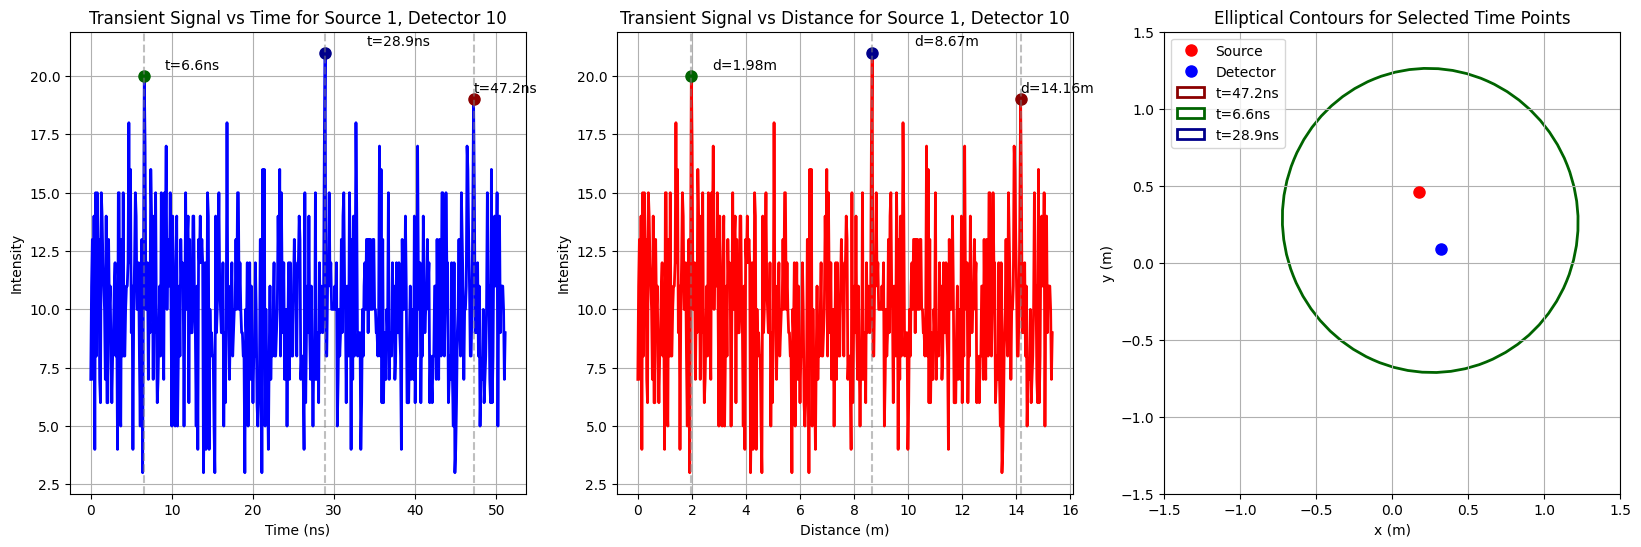

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

def plot_transient_and_ellipses(source_detector_pairs, tpsf, light_speed, s_idx, d_idx, grid_size=256, x_max=1.5):
    """
    Plot a transient signal with separate time and distance x-axes, and elliptical contours
    
    Args:
        source_detector_pairs: Array of shape (num_sources, num_detectors, 4) containing [rs_x, rs_y, rd_x, rd_y]
        tpsf: Time-resolved measurements of shape (num_sources, num_detectors, num_time_bins)
        light_speed: Speed of light in m/s
        s_idx: Source index to plot
        d_idx: Detector index to plot
        grid_size: Size of the reconstruction grid
        x_max: Half-width of the reconstruction region in meters
    """
    c = light_speed[0, 0]  # Speed of light
    time_resolution = 1e-10  # Assuming 1 ns time resolution
    epsilon = 0.015  # 1.5 cm threshold
    
    # Get the transient for the selected source-detector pair
    transient = tpsf[s_idx, d_idx, :]
    
    # Get source and detector positions
    rs_x, rs_y, rd_x, rd_y = source_detector_pairs[s_idx, d_idx]
    
    # Create time axis for the transient
    num_time_bins = transient.shape[0]
    time_axis = np.arange(num_time_bins) * time_resolution  # in seconds
    time_axis_ns = time_axis * 1e9  # convert to nanoseconds for display
    dist_axis = time_axis * c  # in meters (distance = c * t)
    
    # Create figure with 3 subplots side by side
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
    
    # Plot 1: Intensity vs Time
    ax1.plot(time_axis_ns, transient, 'b-', linewidth=2)
    ax1.set_xlabel('Time (ns)')
    ax1.set_ylabel('Intensity')
    ax1.set_title(f'Transient Signal vs Time for Source {s_idx}, Detector {d_idx}')
    ax1.grid(True)
    
    # Plot 2: Intensity vs Distance
    ax2.plot(dist_axis, transient, 'r-', linewidth=2)
    ax2.set_xlabel('Distance (m)')
    ax2.set_ylabel('Intensity')
    ax2.set_title(f'Transient Signal vs Distance for Source {s_idx}, Detector {d_idx}')
    ax2.grid(True)
    
    # Find peaks in the transient for highlighting - using top 3 for clarity
    peak_indices = np.argsort(transient)[-3:]
    
    # Mark peaks on both plots
    colors = ['darkred', 'darkgreen', 'darkblue']
    for i, t_idx in enumerate(peak_indices):
        # Plot 1: Mark peak on time plot
        ax1.plot(time_axis_ns[t_idx], transient[t_idx], 'o', color=colors[i], markersize=8)
        ax1.annotate(f't={time_axis_ns[t_idx]:.1f}ns',
                    (time_axis_ns[t_idx], transient[t_idx]),
                    xytext=(15*i, 5), textcoords='offset points')
        
        # Plot 2: Mark corresponding peak on distance plot at the same index
        ax2.plot(dist_axis[t_idx], transient[t_idx], 'o', color=colors[i], markersize=8)
        ax2.annotate(f'd={dist_axis[t_idx]:.2f}m',
                    (dist_axis[t_idx], transient[t_idx]),
                    xytext=(15*i, 5), textcoords='offset points')
    
    # Add vertical lines to show correspondence between the same points on both plots
    for t_idx in peak_indices:
        ax1.axvline(x=time_axis_ns[t_idx], color='gray', linestyle='--', alpha=0.5)
        ax2.axvline(x=dist_axis[t_idx], color='gray', linestyle='--', alpha=0.5)
    
    # Setup the ellipse visualization subplot
    ax3.set_xlim(-x_max, x_max)
    ax3.set_ylim(-x_max, x_max)
    ax3.set_xlabel('x (m)')
    ax3.set_ylabel('y (m)')
    ax3.set_title('Elliptical Contours for Selected Time Points')
    ax3.grid(True)
    
    # Plot source and detector positions
    ax3.plot(rs_x, rs_y, 'ro', markersize=8, label='Source')
    ax3.plot(rd_x, rd_y, 'bo', markersize=8, label='Detector')
    
    # For each peak, draw the corresponding ellipse
    for i, t_idx in enumerate(peak_indices):
        # Calculate the semi-major axis (half the total path length)
        path_length = c * time_axis[t_idx]  # total path length
        semi_major_axis = path_length / 2
        
        # Calculate distance between source and detector
        source_detector_distance = np.sqrt((rd_x - rs_x)**2 + (rd_y - rs_y)**2)
        
        # Calculate semi-minor axis using the ellipse formula
        # c^2 = a^2 - b^2 where c is half the distance between foci
        semi_minor_axis = np.sqrt(max(0, semi_major_axis**2 - (source_detector_distance/2)**2))
        
        # Calculate center position (midpoint between source and detector)
        center_x = (rs_x + rd_x) / 2
        center_y = (rs_y + rd_y) / 2
        
        # Calculate angle of rotation (angle of the line connecting source and detector)
        angle = np.degrees(np.arctan2(rd_y - rs_y, rd_x - rs_x))
        
        # Create and add the ellipse to the plot
        ellipse = Ellipse(xy=(center_x, center_y), 
                          width=2*semi_major_axis, 
                          height=2*semi_minor_axis,
                          angle=angle,
                          fill=False, 
                          edgecolor=colors[i], 
                          linewidth=2,
                          label=f't={time_axis_ns[t_idx]:.1f}ns')
        ax3.add_patch(ellipse)
    
    ax3.legend()
    # plt.tight_layout()
    plt.show()
    
    return fig

# Main execution
if __name__ == "__main__":
    # Plot transients for two different source-detector pairs
    
    # First pair
    fig1 = plot_transient_and_ellipses(
        source_detector_pairs=source_detector_pairs,
        tpsf=tpsf,
        light_speed=light_speed,
        s_idx=1,  # Using source index 1
        d_idx=10  # Using detector index 10
    )
    

Transient 2 for Source 10, Detector 10

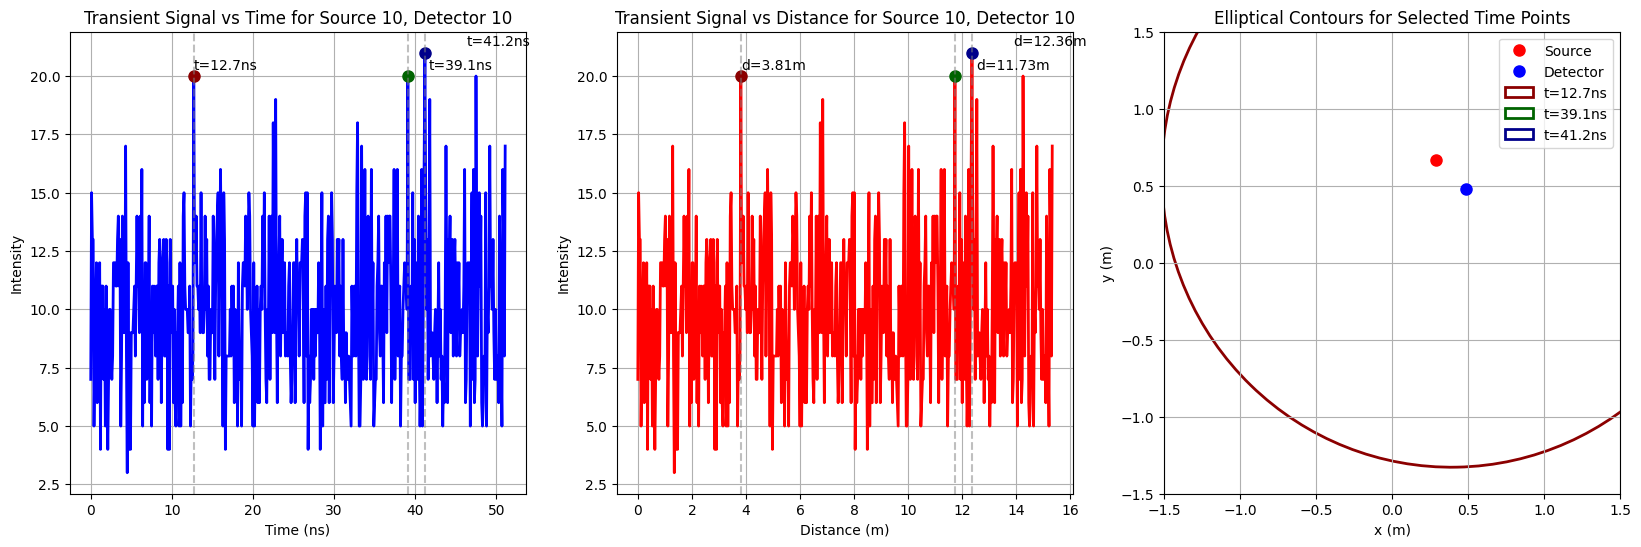

In [89]:
if __name__ == "__main__":
    # Plot transients for two different source-detector pairs
    
    # First pair
    fig1 = plot_transient_and_ellipses(
        source_detector_pairs=source_detector_pairs,
        tpsf=tpsf,
        light_speed=light_speed,
        s_idx=10,  # Using source index 1
        d_idx=10  # Using detector index 10
    )

# Question 2

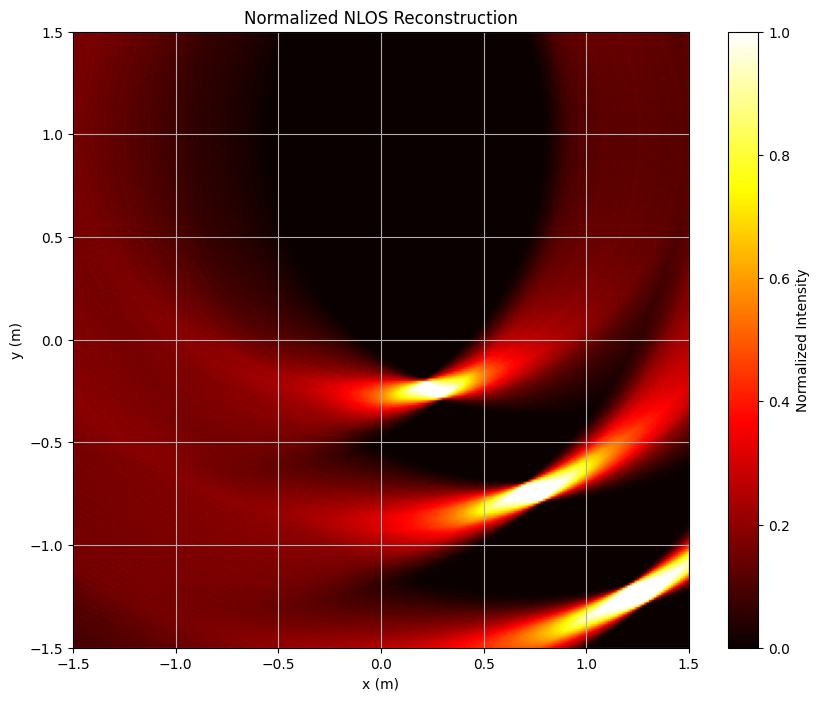

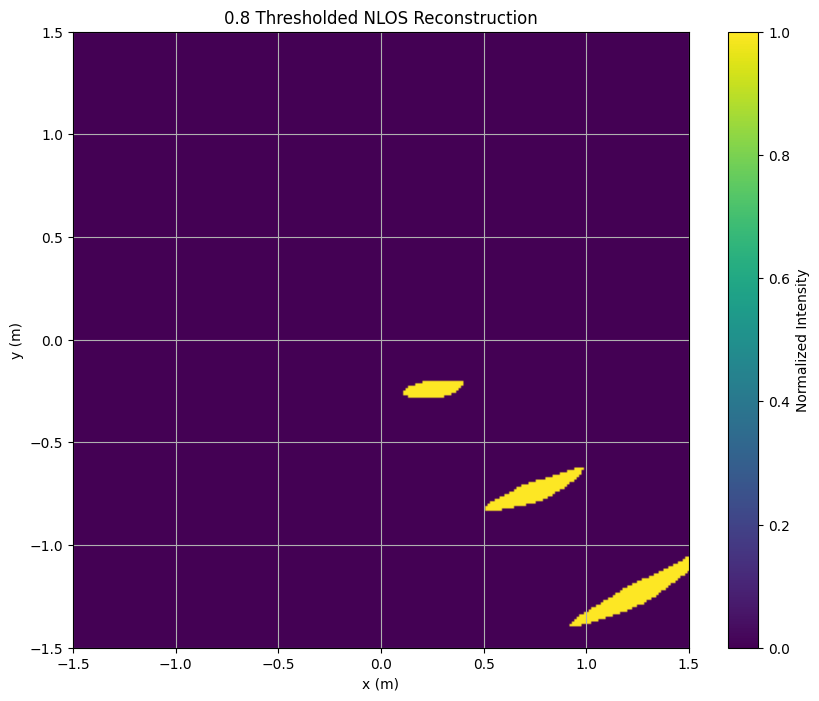

In [67]:
def analyze_nlos_reconstruction(accumulator, x_max=1.5):
    """
    Normalize and analyze the NLOS reconstruction
    
    Args:
        accumulator: The vote accumulator from reconstruction
        x_max: Half-width of the reconstruction region in meters
        
    Returns:
        normalized_image: The normalized reconstruction image
    """
    # Normalize the accumulator to [0, 1]
    normalized_image = (accumulator - accumulator.min()) / (accumulator.max() - accumulator.min())
    
    # Display the normalized image
    plt.figure(figsize=(10, 8))
    plt.imshow(normalized_image, cmap='hot', extent=[-x_max, x_max, -x_max, x_max])
    plt.colorbar(label='Normalized Intensity')
    plt.title('Normalized NLOS Reconstruction')
    plt.xlabel('x (m)')
    plt.ylabel('y (m)')
    plt.grid(True)
    
    # Apply thresholding to identify objects
    # Start with a high threshold to identify bright regions
    threshold = 0.8  # Adjust as needed
    binary_image = normalized_image > threshold
    
    
        # Display the normalized image
    plt.figure(figsize=(10, 8))
    plt.imshow(binary_image, extent=[-x_max, x_max, -x_max, x_max])
    plt.colorbar(label='Normalized Intensity')
    plt.title(f'{threshold} Thresholded NLOS Reconstruction')
    plt.xlabel('x (m)')
    plt.ylabel('y (m)')
    plt.grid(True)
    plt.show()
    return normalized_image, binary_image

# Use the function with the accumulator from reconstruct_nlos_image
normalized_image, binary_image = analyze_nlos_reconstruction(accumulator, x_max=1.5)

From the reconstructed image, the three objects appear located at the xy coordinate of (0.25,-0.25), (1.5, -1.5), and (1.25, -1.25). This could be multiple reflections from a single object (primary and secondary reflections). However, the curved nature of these paths suggests they represent different optical path lengths from the light source to detector after bouncing off hidden surfaces. Therefore, based on the saperated countour pattern,  we can conclude the number of objects is most likely to be 3.

# Question 3

Reconstructing NLOS image with grid size 256x256
Using epsilon thickness of 1.5 cm


/var/folders/6q/b1f95jp528qg7gf5zww7z9h80000gn/T/ipykernel_36664/2407182168.py:58: RuntimeWarning: overflow encountered in scalar multiply
  expected_path_length = c * t * 1e-10


Reconstruction complete!


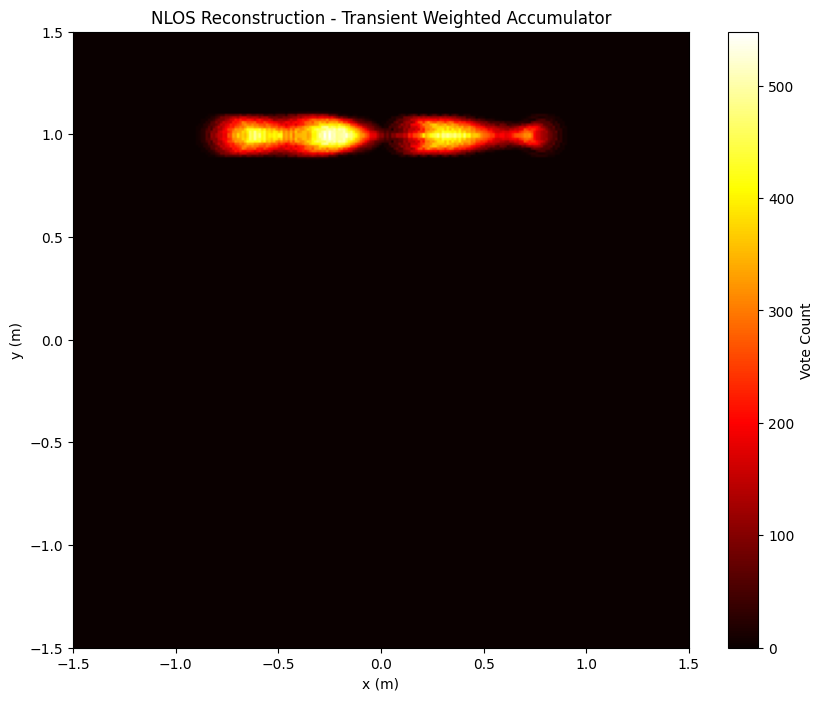

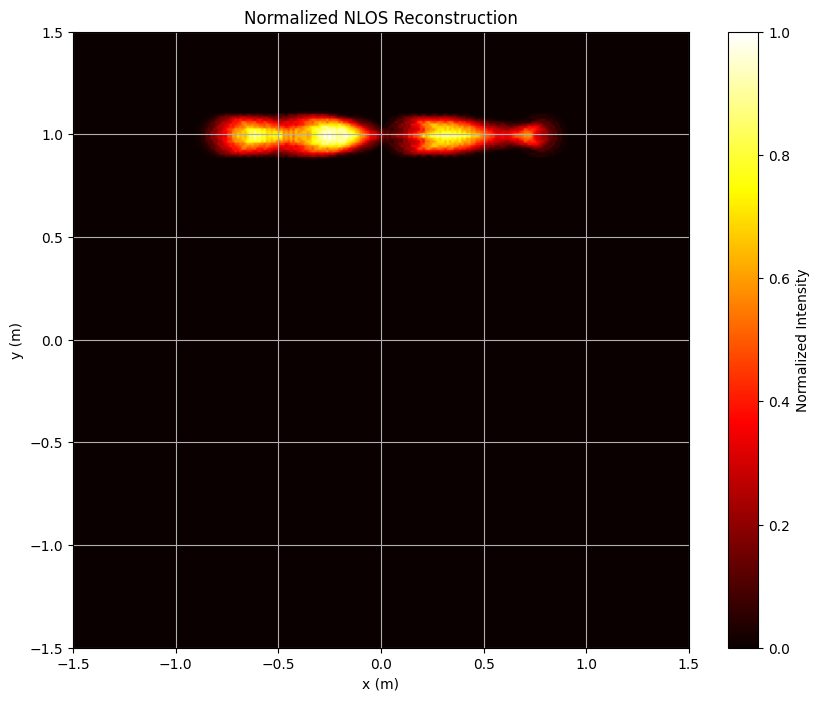

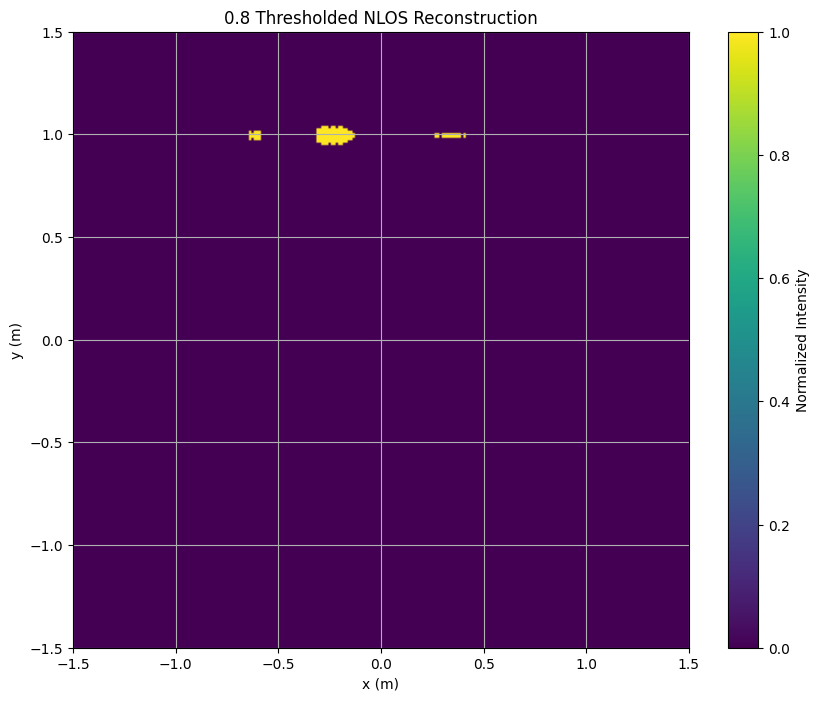

In [68]:
def reconstruct_nlos_image(source_detector_pairs, tpsf, light_speed, grid_size=256, x_max=1.5):
    """
    Reconstruct NLOS image using elliptical backprojection with proper ellipse thickness
    
    Args:
        source_detector_pairs: Array of shape (num_sources, num_detectors, 4) containing [rs_x, rs_y, rd_x, rd_y]
        tpsf: Time-resolved measurements of shape (num_sources, num_detectors, num_time_bins)
        light_speed: Speed of light in m/s
        grid_size: Size of the reconstruction grid (grid_size × grid_size)
        x_max: Half-width of the reconstruction region in meters
        
    Returns:
        accumulator: The reconstructed image based on vote counting
    """
    # Set up the reconstruction grid
    x = np.linspace(-x_max, x_max, grid_size)
    y = np.linspace(-x_max, x_max, grid_size)
    X, Y = np.meshgrid(x, y)
    
    # Initialize accumulator for vote counting
    accumulator = np.zeros((grid_size, grid_size))
    
    # Define epsilon threshold for ellipse thickness (1-2 cm)
    epsilon_distance = 0.015  # 1.5 cm threshold
    
    num_sources, num_detectors, num_time_bins = tpsf.shape
    c = light_speed[0, 0]  # Speed of light
    time_resolution = 1e-9
    
    print(f"Reconstructing NLOS image with grid size {grid_size}x{grid_size}")
    print(f"Using epsilon thickness of {epsilon_distance*100:.1f} cm")
    
    # For each source-detector pair
    for s in range(num_sources):
        for d in range(num_detectors):
            # Skip if needed (e.g., for testing with fewer pairs)
            # if s % 4 != 0 or d % 4 != 0:  # Example: use only 1/16 of pairs for speed
            #     continue
                
            # Get source and detector positions
            rs_x, rs_y, rd_x, rd_y = source_detector_pairs[s, d]
            
            # Calculate distances from each grid point to source and detector
            dist_to_source = np.sqrt((X - rs_x)**2 + (Y - rs_y)**2)
            dist_to_detector = np.sqrt((X - rd_x)**2 + (Y - rd_y)**2)
            
            # Total path lengths for all grid points
            total_path_lengths = dist_to_source + dist_to_detector
            
            # For each time bin
            for t in range(num_time_bins):
                # Skip if no photons detected or below threshold
                if tpsf[s, d, t] <= 0:
                    continue
                
                # t *= 1e-10
                # Calculate the expected path length for this time bin
                expected_path_length = c * t * 1e-10
                
                # Find grid points where the difference between total path length 
                # and expected path length is within epsilon_distance
                # This implements: if abs(dist(x, y) - c*t) < epsilon:
                ellipse_points = np.abs(total_path_lengths - expected_path_length) < epsilon_distance
                
                # print(ellipse_points.shape)
                # print(tpsf[s, d, t])
                # Option 2: Weighted voting (weight by photon count)
                accumulator += ellipse_points * tpsf[s, d, t]
                
    
    print("Reconstruction complete!")
    return accumulator

# Main execution
if __name__ == "__main__":
    # Your data is already loaded
    # source_detector_pairs shape: (32, 32, 4)
    # tpsf shape: (32, 32, 512)
    # light_speed: [[300000000]]
    
    # Reconstruct the image
    weighted_accumulator = reconstruct_nlos_image(
        source_detector_pairs=source_detector_pairs,
        tpsf=tpsf,
        light_speed=light_speed,
        grid_size=256,
        x_max=1.5
    )
    
    # Visualize the result
    plt.figure(figsize=(10, 8))
    plt.imshow(weighted_accumulator, cmap='hot', extent=[-1.5, 1.5, -1.5, 1.5])
    plt.colorbar(label='Vote Count')
    plt.title('NLOS Reconstruction - Transient Weighted Accumulator')
    plt.xlabel('x (m)')
    plt.ylabel('y (m)')
    plt.show()

    # Use the function with the accumulator from reconstruct_nlos_image
normalized_image, binary_image = analyze_nlos_reconstruction(weighted_accumulator, x_max=1.5)

This multiplies the ellipse points by the transient value at time bin t for the given source-detector pair. This means:

For each point that falls within the elliptical shell (where ellipse_points is True), instead of adding 1 to the accumulator, you add the actual photon count from the TPSF.
Higher intensity measurements in the transient will contribute more to the reconstruction than lower intensity measurements.

This is a form of intensity-weighted backprojection, which generally gives better results than binary accumulation because:

It preserves the relative strength of different reflections
It gives more importance to strong signals and less to weak ones (which might be noise)
It provides better contrast in the final reconstruction

The commented "Option 3" takes this even further by not just weighting by intensity, but also by how close each point is to the exact ellipse (points exactly on the ellipse get full weight, while points near the edge of the epsilon threshold get less weight).
Using intensity weighting is typically a good approach for NLOS imaging as it better represents the physical meaning of the measurements - stronger reflections should contribute more to the final image than weaker ones.

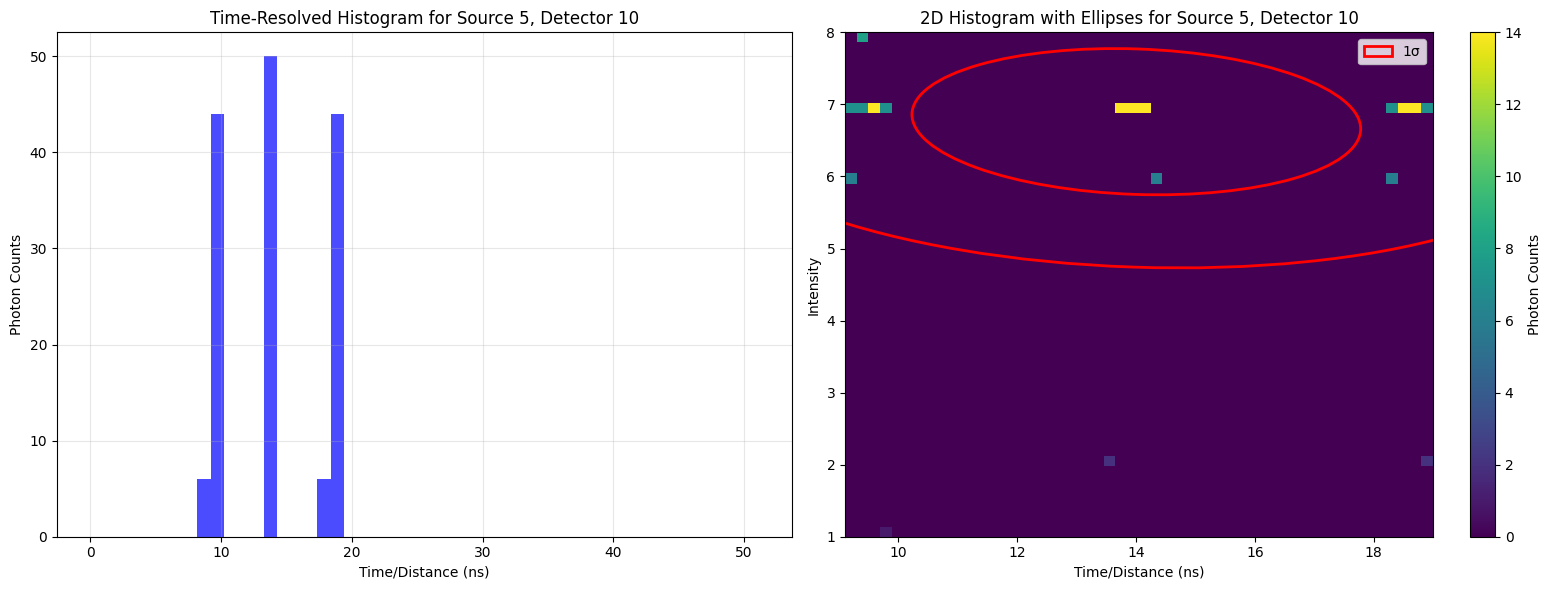

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy import stats

def plot_transient_and_ellipses(source_detector_pairs, tpsf, light_speed, bin_width, num_bins, s_idx, d_idx, grid_size=256, x_max=1.5):
    """
    Plot a time-resolved histogram and 2D histogram with ellipse contours for photon arrivals.

    Args:
        source_detector_pairs: Array of shape (32, 32, 4) containing [rs_x, rs_y, rd_x, rd_y]
        tpsf: Time-resolved measurements of shape (32, 32, 512)
        light_speed: Speed of light in m/s, shape (1, 1)
        bin_width: Width of each time bin in seconds, shape (1, 1)
        num_bins: Number of time bins, shape (1, 1)
        s_idx: Source index to plot (0 to 31)
        d_idx: Detector index to plot (0 to 31)
        grid_size: Size of the reconstruction grid (unused)
        x_max: Half-width of the reconstruction region in meters (unused)
    """
    c = light_speed[0, 0]  # Speed of light (3e8 m/s)
    time_resolution = bin_width[0, 0]  # 1e-10 s (100 ps)
    num_time_bins = int(num_bins[0, 0])  # 512 bins

    # Get the transient for the selected source-detector pair
    transient = tpsf[s_idx, d_idx, :]  # Shape: (512,)

    # Create time axis for the transient
    time_axis = np.arange(num_time_bins) * time_resolution  # in seconds
    time_axis_ns = time_axis * 1e9  # convert to nanoseconds for display
    dist_axis = time_axis * c  # in meters (distance = c * t)

    # Create figure with 2 subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Time-Resolved Histogram
    # Use histogram to show photon counts vs. time/distance
    bins = 50  # Number of bins for histogram
    ax1.hist(time_axis_ns, bins=bins, weights=transient, alpha=0.7, color='blue')
    ax1.set_xlabel('Time/Distance (ns)')
    ax1.set_ylabel('Photon Counts')
    ax1.set_title(f'Time-Resolved Histogram for Source {s_idx}, Detector {d_idx}')
    ax1.grid(True, alpha=0.3)

    # Plot 2: 2D Histogram with Ellipse Contours
    # Generate data for 2D histogram: time vs. intensity
    # Since tpsf gives counts per bin, simulate photon arrivals by repeating times based on counts
    photon_times = []
    photon_intensities = []
    for t_idx, count in enumerate(transient):
        if count > 0:
            # Repeat the time and assign intensity (here, intensity is the count)
            photon_times.extend([time_axis_ns[t_idx]] * int(count))
            photon_intensities.extend([count] * int(count))

    photon_times = np.array(photon_times)
    photon_intensities = np.array(photon_intensities)

    if len(photon_times) > 0:
        # Create 2D histogram
        hist, xedges, yedges = np.histogram2d(photon_times, photon_intensities, bins=50)
        ax2.imshow(hist.T, origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                   interpolation='nearest', aspect='auto', cmap='viridis')
        ax2.set_xlabel('Time/Distance (ns)')
        ax2.set_ylabel('Intensity')
        ax2.set_title(f'2D Histogram with Ellipses for Source {s_idx}, Detector {d_idx}')
        plt.colorbar(ax2.images[0], ax=ax2, label='Photon Counts')

        # Compute covariance ellipse
        data = np.vstack((photon_times, photon_intensities))
        mean = np.mean(data, axis=1)
        cov = np.cov(data)

        # Eigenvalues and eigenvectors for ellipse
        eigenvals, eigenvecs = np.linalg.eigh(cov)
        order = eigenvals.argsort()[::-1]
        eigenvals, eigenvecs = eigenvals[order], eigenvecs[:, order]
        angle = np.degrees(np.arctan2(*eigenvecs[:, 0][::-1]))

        # Ellipse parameters for 1σ and 2σ
        for n_sigma in [1, 2]:
            width, height = 2 * n_sigma * np.sqrt(eigenvals)
            ell = Ellipse(xy=mean, width=width, height=height, angle=angle,
                          edgecolor='red', fc='none', lw=2, label=f'{n_sigma}σ' if n_sigma == 1 else None)
            ax2.add_patch(ell)

        ax2.legend()

    else:
        ax2.text(0.5, 0.5, 'No photon data', ha='center', va='center', transform=ax2.transAxes)
        ax2.set_xlabel('Time/Distance (ns)')
        ax2.set_ylabel('Intensity')
        ax2.set_title(f'2D Histogram with Ellipses for Source {s_idx}, Detector {d_idx}')

    plt.tight_layout()
    plt.show()

    return fig

# Main execution
if __name__ == "__main__":
    # Placeholder for actual data (replace with your actual data)
    # num_sources, num_detectors, num_time_bins = 32, 32, 512
    # source_detector_pairs = np.random.uniform(low=-1.0, high=0.8, size=(num_sources, num_detectors, 4))  # [rs_x, rs_y, rd_x, rd_y]
    # tpsf = np.random.poisson(lam=10, size=(num_sources, num_detectors, num_time_bins))  # Photon counts
    # light_speed = np.array([[3e8]])  # Speed of light in m/s
    # bin_width = np.array([[1e-10]])  # 100 ps
    # num_bins = np.array([[512]])  # 512 time bins

    # Plot transients for one source-detector pair
    fig1 = plot_transient_and_ellipses(
        source_detector_pairs=source_detector_pairs,
        tpsf=tpsf,
        light_speed=light_speed,
        bin_width=bin_width,
        num_bins=num_bins,
        s_idx=5,  # Source index 5
        d_idx=10  # Detector index 10
    )

    # # Second pair (uncomment if needed)
    # fig2 = plot_transient_and_ellipses(
    #     source_detector_pairs=source_detector_pairs,
    #     tpsf=tpsf,
    #     light_speed=light_speed,
    #     bin_width=bin_width,
    #     num_bins=num_bins,
    #     s_idx=1,  # Source index 1
    #     d_idx=10  # Detector index 10
    # )

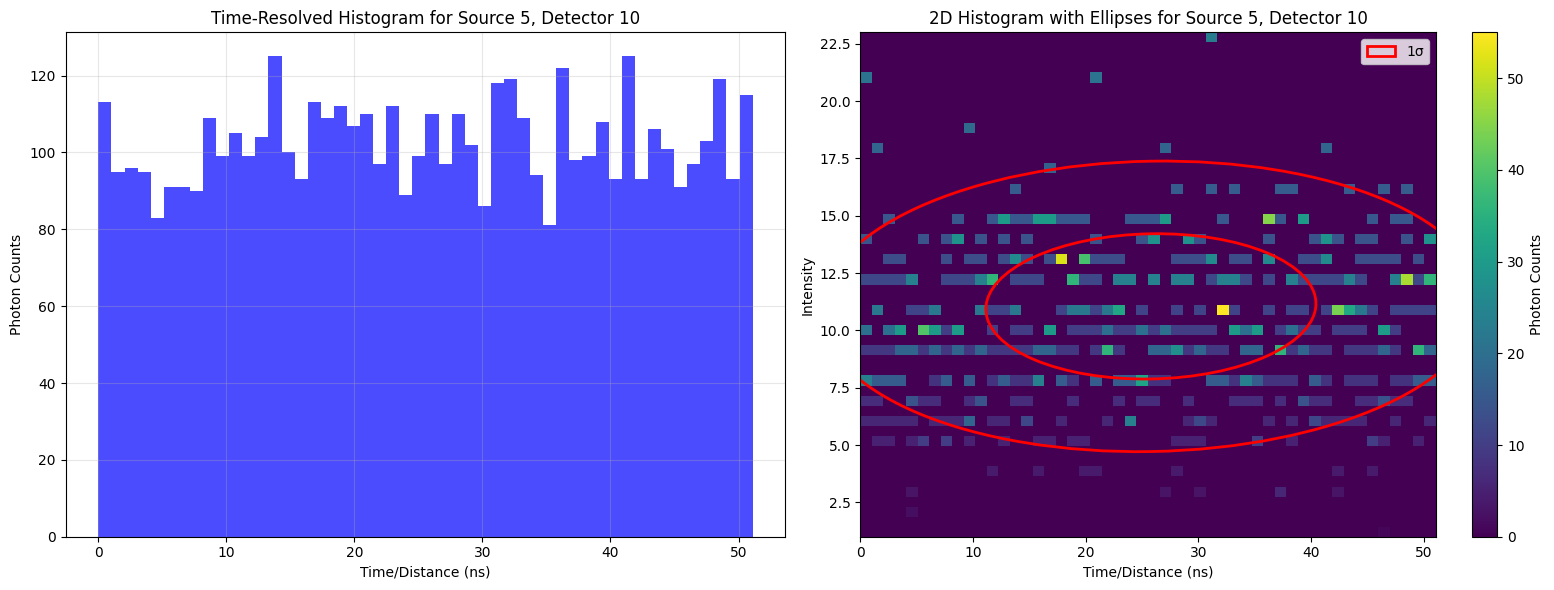

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy import stats

def plot_transient_and_ellipses(source_detector_pairs, tpsf, light_speed, bin_width, s_idx, d_idx, grid_size=256, x_max=1.5):
    """
    Plot a time-resolved histogram and 2D histogram with ellipse contours for photon arrivals across all time bins.

    Args:
        source_detector_pairs: Array of shape (32, 32, 4) containing [rs_x, rs_y, rd_x, rd_y]
        tpsf: Time-resolved measurements of shape (32, 32, 512)
        light_speed: Speed of light in m/s, shape (1, 1)
        bin_width: Width of each time bin in seconds, shape (1, 1)
        s_idx: Source index to plot (0 to 31)
        d_idx: Detector index to plot (0 to 31)
        grid_size: Size of the reconstruction grid (unused)
        x_max: Half-width of the reconstruction region in meters (unused)
    """
    c = light_speed[0, 0]  # Speed of light (3e8 m/s)
    time_resolution = bin_width[0, 0]  # 1e-10 s (100 ps)

    # Get the transient for the selected source-detector pair
    transient = tpsf[s_idx, d_idx, :]  # Shape: (512,)

    # Get source and detector positions (for context, not used in plots)
    rs_x, rs_y, rd_x, rd_y = source_detector_pairs[s_idx, d_idx]

    # Create time axis for the transient
    num_time_bins = transient.shape[0]  # 512
    time_axis = np.arange(num_time_bins) * time_resolution  # in seconds
    time_axis_ns = time_axis * 1e9  # convert to nanoseconds for display
    dist_axis = time_axis * c  # in meters (distance = c * t)

    # Create figure with 2 subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Time-Resolved Histogram
    # Histogram of photon counts vs. time/distance
    bins = 50  # Number of bins for histogram
    ax1.hist(time_axis_ns, bins=bins, weights=transient, alpha=0.7, color='blue')
    ax1.set_xlabel('Time/Distance (ns)')
    ax1.set_ylabel('Photon Counts')
    ax1.set_title(f'Time-Resolved Histogram for Source {s_idx}, Detector {d_idx}')
    ax1.grid(True, alpha=0.3)

    # Plot 2: 2D Histogram with Ellipse Contours
    # Generate data for 2D histogram: time vs. intensity for all time bins
    photon_times = []
    photon_intensities = []
    for t_idx, count in enumerate(transient):
        if count > 0:
            # Repeat the time and assign intensity (intensity = photon count in bin)
            photon_times.extend([time_axis_ns[t_idx]] * int(count))
            photon_intensities.extend([count] * int(count))

    photon_times = np.array(photon_times)
    photon_intensities = np.array(photon_intensities)

    if len(photon_times) > 0:
        # Create 2D histogram
        hist, xedges, yedges = np.histogram2d(photon_times, photon_intensities, bins=50)
        ax2.imshow(hist.T, origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                   interpolation='nearest', aspect='auto', cmap='viridis')
        ax2.set_xlabel('Time/Distance (ns)')
        ax2.set_ylabel('Intensity')
        ax2.set_title(f'2D Histogram with Ellipses for Source {s_idx}, Detector {d_idx}')
        plt.colorbar(ax2.images[0], ax=ax2, label='Photon Counts')

        # Compute covariance ellipse
        data = np.vstack((photon_times, photon_intensities))
        mean = np.mean(data, axis=1)
        cov = np.cov(data)

        # Eigenvalues and eigenvectors for ellipse
        eigenvals, eigenvecs = np.linalg.eigh(cov)
        order = eigenvals.argsort()[::-1]
        eigenvals, eigenvecs = eigenvals[order], eigenvecs[:, order]
        angle = np.degrees(np.arctan2(*eigenvecs[:, 0][::-1]))

        # Ellipse parameters for 1σ and 2σ
        for n_sigma in [1, 2]:
            width, height = 2 * n_sigma * np.sqrt(eigenvals)
            ell = Ellipse(xy=mean, width=width, height=height, angle=angle,
                          edgecolor='red', fc='none', lw=2, label=f'{n_sigma}σ' if n_sigma == 1 else None)
            ax2.add_patch(ell)

        ax2.legend()

    else:
        ax2.text(0.5, 0.5, 'No photon data', ha='center', va='center', transform=ax2.transAxes)
        ax2.set_xlabel('Time/Distance (ns)')
        ax2.set_ylabel('Intensity')
        ax2.set_title(f'2D Histogram with Ellipses for Source {s_idx}, Detector {d_idx}')

    plt.tight_layout()
    plt.show()

    return fig

# Main execution
if __name__ == "__main__":
    # Placeholder for actual data (replace with your actual data)
    num_sources, num_detectors, num_time_bins = 32, 32, 512
    source_detector_pairs = np.random.uniform(low=-1.0, high=0.8, size=(num_sources, num_detectors, 4))  # [rs_x, rs_y, rd_x, rd_y]
    tpsf = np.random.poisson(lam=10, size=(num_sources, num_detectors, num_time_bins))  # Photon counts
    light_speed = np.array([[3e8]])  # Speed of light in m/s
    bin_width = np.array([[1e-10]])  # 100 ps

    # Plot transients for one source-detector pair
    fig1 = plot_transient_and_ellipses(
        source_detector_pairs=source_detector_pairs,
        tpsf=tpsf,
        light_speed=light_speed,
        bin_width=bin_width,
        s_idx=5,  # Source index 5
        d_idx=10  # Detector index 10
    )

    # # Second pair (uncomment if needed)
    # fig2 = plot_transient_and_ellipses(
    #     source_detector_pairs=source_detector_pairs,
    #     tpsf=tpsf,
    #     light_speed=light_speed,
    #     bin_width=bin_width,
    #     s_idx=1,  # Source index 1
    #     d_idx=10  # Detector index 10
    # )